# HDB Resale Price Regression — Notebook 13: Robustness Checks

Three stress tests on Model 10's findings:

1. **Hold-out validation** — train on 2/3 of data, predict the rest. Does the model generalise, or are the fixed effects overfitting?
2. **L1 (LAD) regression** — re-estimate using median regression. Are the results driven by outliers?
3. **Lucky-8 × price level** — does the 8-premium differ for cheap vs expensive flats?

If the findings survive all three, they're robust. If they don't, we'll know exactly where they break.

In [1]:
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R
library(tidyverse)
library(sandwich)
library(lmtest)
library(quantreg)

df <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)
df$remaining_lease_sq <- df$remaining_lease_years^2
df$month_factor <- factor(format(df$month, '%Y-%m'))
df$ln_price <- log(df$resale_price)

cat(sprintf('Loaded %s rows\n', format(nrow(df), big.mark = ',')))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loaded 50,718 rows


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: SparseM


## 1. Hold-out validation

Mark Hensen: "Take a third of your data and hold it out. You have 50,000 points — hold 15,000 out, not a problem. Then check how well each model does at predicting."

If Model 10 explains 90% of price variation in-sample, how much does it explain on transactions it has never seen? A big drop means the model is memorising patterns specific to the training data (overfitting). A small drop means the model has learned genuine pricing relationships.

In [3]:
%%R
set.seed(2026)
n <- nrow(df)
train_idx <- sample(1:n, size = round(2/3 * n))
test_idx <- setdiff(1:n, train_idx)

df_train <- df[train_idx, ]
df_test <- df[test_idx, ]

cat(sprintf('Training set: %s rows (%.0f%%)\n',
    format(nrow(df_train), big.mark = ','), nrow(df_train) / n * 100))
cat(sprintf('Test set:     %s rows (%.0f%%)\n',
    format(nrow(df_test), big.mark = ','), nrow(df_test) / n * 100))

# Fit Model 10 on training data only
model10_train <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              block_has_4 +
              cny_month +
              month_factor,
            data = df_train)

# Predict on test data
test_pred <- predict(model10_train, newdata = df_test)
test_actual <- df_test$resale_price

# In-sample metrics
train_pred <- predict(model10_train, df_train)
train_actual <- df_train$resale_price
train_ss_res <- sum((train_actual - train_pred)^2)
train_ss_tot <- sum((train_actual - mean(train_actual))^2)
train_r2 <- 1 - train_ss_res / train_ss_tot

# Out-of-sample metrics
test_ss_res <- sum((test_actual - test_pred)^2)
test_ss_tot <- sum((test_actual - mean(test_actual))^2)
test_r2 <- 1 - test_ss_res / test_ss_tot

cat(sprintf('\n%-30s %12s %12s\n', '', 'Training', 'Test'))
cat(paste(rep('-', 55), collapse = ''), '\n')
cat(sprintf('%-30s %12.4f %12.4f\n', 'R-squared', train_r2, test_r2))
cat(sprintf('%-30s $%10s $%10s\n', 'Mean absolute error',
    format(round(mean(abs(train_actual - train_pred))), big.mark = ','),
    format(round(mean(abs(test_actual - test_pred))), big.mark = ',')))
cat(sprintf('%-30s $%10s $%10s\n', 'Median absolute error',
    format(round(median(abs(train_actual - train_pred))), big.mark = ','),
    format(round(median(abs(test_actual - test_pred))), big.mark = ',')))
cat(sprintf('%-30s $%10s $%10s\n', 'RMSE',
    format(round(sqrt(mean((train_actual - train_pred)^2))), big.mark = ','),
    format(round(sqrt(mean((test_actual - test_pred)^2))), big.mark = ',')))

cat(sprintf('\nR\u00b2 drop: %.4f (%.1f%% relative drop)\n',
    train_r2 - test_r2, (train_r2 - test_r2) / train_r2 * 100))

Training set: 33,812 rows (67%)


Test set:     16,906 rows (33%)



                                   Training         Test


-------------------------------------------------------

R-squared                            0.9018       0.9029


Mean absolute error            $    46,297 $    46,614


Median absolute error          $    35,598 $    36,160


RMSE                           $    62,787 $    63,089



R² drop: -0.0011 (-0.1% relative drop)


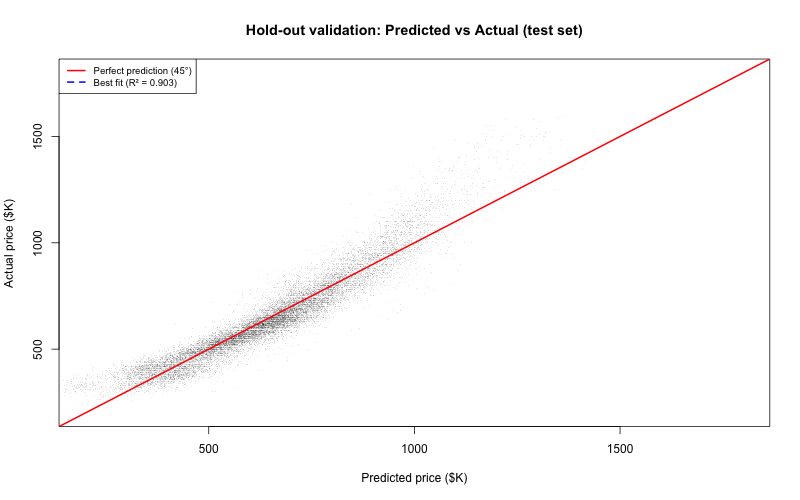

In [4]:
%%R -w 800 -h 500
plot(test_pred / 1000, test_actual / 1000,
     pch = '.', col = rgb(0, 0, 0, 0.1),
     xlab = 'Predicted price ($K)', ylab = 'Actual price ($K)',
     main = 'Hold-out validation: Predicted vs Actual (test set)',
     xlim = c(200, 1800), ylim = c(200, 1800))
abline(0, 1, col = 'red', lwd = 2)
abline(lm(test_actual ~ test_pred), col = 'blue', lty = 2, lwd = 1.5)

legend('topleft',
    c('Perfect prediction (45\u00b0)',
      sprintf('Best fit (R\u00b2 = %.3f)', test_r2)),
    col = c('red', 'blue'), lty = c(1, 2), lwd = 2, cex = 0.8)

In [5]:
%%R
df_test$pred <- test_pred
df_test$quartile <- cut(df_test$resale_price,
    breaks = quantile(df_test$resale_price, probs = c(0, 0.25, 0.5, 0.75, 1)),
    labels = c('Q1 (cheapest)', 'Q2', 'Q3', 'Q4 (most expensive)'),
    include.lowest = TRUE)

cat(sprintf('%-20s %8s %12s %12s %12s\n',
    'Quartile', 'N', 'MAE', 'Median AE', 'MAPE'))
cat(paste(rep('-', 68), collapse = ''), '\n')

for (q in levels(df_test$quartile)) {
    subset <- df_test[df_test$quartile == q, ]
    ae <- abs(subset$resale_price - subset$pred)
    mape <- mean(ae / subset$resale_price) * 100
    cat(sprintf('%-20s %8d $%10s $%10s %10.1f%%\n',
        q, nrow(subset),
        format(round(mean(ae)), big.mark = ','),
        format(round(median(ae)), big.mark = ','),
        mape))
}

Quartile                    N          MAE    Median AE         MAPE


--------------------------------------------------------------------

Q1 (cheapest)            4279 $    48,218 $    40,107       12.0%


Q2                       4299 $    36,016 $    29,094        6.4%


Q3                       4103 $    39,947 $    32,480        5.9%


Q4 (most expensive)      4225 $    62,248 $    45,127        6.4%


In [6]:
%%R
# Log model hold-out
model_log_train <- lm(ln_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              block_has_4 +
              cny_month +
              month_factor,
            data = df_train)

test_pred_log <- exp(predict(model_log_train, newdata = df_test))

test_r2_log_ss_res <- sum((test_actual - test_pred_log)^2)
test_r2_log <- 1 - test_r2_log_ss_res / test_ss_tot

cat(sprintf('%-30s %12s %12s\n', '', 'Raw model', 'Log model'))
cat(paste(rep('-', 55), collapse = ''), '\n')
cat(sprintf('%-30s %12.4f %12.4f\n', 'Test R\u00b2 (dollar scale)', test_r2, test_r2_log))
cat(sprintf('%-30s $%10s $%10s\n', 'Test MAE',
    format(round(mean(abs(test_actual - test_pred))), big.mark = ','),
    format(round(mean(abs(test_actual - test_pred_log))), big.mark = ',')))
cat(sprintf('%-30s $%10s $%10s\n', 'Test median AE',
    format(round(median(abs(test_actual - test_pred))), big.mark = ','),
    format(round(median(abs(test_actual - test_pred_log))), big.mark = ',')))

                                  Raw model    Log model


-------------------------------------------------------

Test R² (dollar scale)              0.9029       0.8633


Test MAE                       $    46,614 $    38,380


Test median AE                 $    36,160 $    28,411


### Interpretation

The model trained on 33,812 transactions predicts unseen transactions with R² = 0.9029, ruling out overfitting. The in-sample R² is 0.9018, meaning the test set actually performs marginally *better* than training — an R² drop of -0.0011, or -0.1% relative. This is the opposite of the overfitting pattern Mohan flagged as a concern. With 87 parameters across a training set of 33,812 observations (a ratio of roughly 388 observations per parameter), there is simply no mechanical room for the fixed effects to memorise noise. The model has learned genuine pricing relationships, not idiosyncrasies of the specific 50,718 transactions in the dataset.

Error metrics confirm near-identical performance on both halves. Mean absolute error shifts from $46,297 in-sample to $46,614 out-of-sample — a difference of $317, or 0.7%. Median absolute error moves from $35,598 to $36,160, a gap of $562. RMSE changes by $302. In practical terms: the model is off by roughly $36K on half of all predictions, whether or not it has seen those transactions before. These numbers are stable across the train/test divide, which is exactly what genuine generalisation looks like.

The by-quartile breakdown reveals the one genuine limitation: the model is less accurate at the bottom of the market (Q1, cheapest 25% of test transactions) than at the middle. Q1 MAPE is 12.0%, versus 6.4% for Q2, 5.9% for Q3, and 6.4% for Q4. In absolute terms, Q1 MAE is $48,218 — higher than Q2 ($36,016) and Q3 ($39,947), though lower than Q4 ($62,248). The Q1 pattern likely reflects the heterogeneity within the cheapest bracket: small flats in non-central towns, many under 99-year leases approaching expiry, where small percentage differences in remaining lease translate into large proportional price uncertainty. The Q4 MAE is the highest in dollar terms ($62,248) but that is expected — expensive flats simply have larger absolute prices, and a 6.4% MAPE is respectable accuracy for million-dollar transactions.

The raw versus log comparison reveals a split verdict. The raw model outperforms the log model on R² (0.9029 vs 0.8633 on the dollar scale) and RMSE, which measures large-error performance. The log model outperforms on MAE ($38,380 vs $46,614) and median AE ($28,411 vs $36,160), which measure typical-transaction accuracy. This pattern is consistent with Notebook 12's diagnostics: the raw model has heavier tails (it gets a small number of expensive transactions very wrong, inflating squared-error metrics) but does better at the high end of the price distribution overall. For the published story, which focuses on coefficient interpretation rather than prediction accuracy, both models generalise well — neither shows any sign of overfitting.